# PBCO historgram plot of all the modes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import pandas as pd
import tensorflow as tf
from importlib import reload
import P2_alris_one_third_functions as P2_alris_one_third_functions
reload(P2_alris_one_third_functions)
from P2_alris_one_third_functions import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list

number_of_modes = 52

structure_type = 'P2'
path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type


In [2]:
def fn_all_hkl_list():
    all_h_list = np.linspace(0 , -4.666666 , 15)
    all_k_list = np.linspace(0 , 4.666666 , 15) 
    all_l_list = np.linspace(0 , 12 , 5) 
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = tf.convert_to_tensor(all_hkl_list, dtype=tf.float32)
    return all_hkl_list

def make_hkl_indices(hkl_list , experimental_data): 
    hkl_list = np.array(hkl_list, dtype=np.float32) * 3
    hkl_list = np.round(hkl_list).astype(int)
    hkl_list = pd.DataFrame(hkl_list, columns=['h', 'k', 'l'])

    all_h_list = np.linspace(0 , -4.666666 , 15) * 3
    all_k_list = np.linspace(0 , 4.666666 , 15) * 3
    all_l_list = np.linspace(0 , 12 , 5) * 3
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = np.round(all_hkl_list).astype(int)
    all_hkl_list = pd.DataFrame(all_hkl_list, columns=['h', 'k', 'l'])

    merged = all_hkl_list.merge(hkl_list, how='left', indicator=True)
    hkl_indices = merged[merged['_merge'] == 'both'].index.tolist()

    #retrive hkl values from all_hkl_list using hkl_indices
    hkl_from_indices = all_hkl_list.iloc[hkl_indices].values.tolist()

    reordered_hkl_list = pd.DataFrame(hkl_from_indices, columns=['h', 'k', 'l'])


    experimental_data[['h', 'k', 'l']] = experimental_data[['h', 'k', 'l']] * 3 
    experimental_data[['h', 'k', 'l']] = np.round(experimental_data[['h', 'k', 'l']]).astype(int)

    #find the intensity values from experimental_data corresponding to the reordered_hkl_list
    intensity = []
    for index, row in reordered_hkl_list.iterrows():
        h = row['h']
        k = row['k']
        l = row['l']
        intensity_value = experimental_data[(experimental_data['h'] == h) & (experimental_data['k'] == k) & (experimental_data['l'] == l)]['intensity_exp'].values
        
        if len(intensity_value) > 0:
            intensity.append(intensity_value[0])
        else:
            intensity.append(0)

    reordered_hkl_list = np.array(hkl_from_indices, dtype=np.float32) / 3
    hkl_indices = tf.convert_to_tensor(hkl_indices, dtype=tf.int32)

    return hkl_indices , reordered_hkl_list , intensity

In [3]:
def fun_tf(hkl_list, pars, matrix , hkl_indices):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """
    # stack parameters
    pars_tensor = tf.stack(pars)  # shape (params,)

    atom_shift_list = shift_atoms(matrix , (pars_tensor))
    atom_shift_list = atom_shift_list[:,0]
    atom_shift_list = tf.unstack(atom_shift_list)

    modified_struct = atom_position_list(*atom_shift_list)
    all_hkl_list = fn_all_hkl_list()
    all_hkl_list = transform_list_hkl_p63_p65(all_hkl_list)

    # Get structure factors
    sf_hkl = get_structure_factors(all_hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(all_hkl_list, tf.float32), axis=1)
    intensity = intensity * tf.exp(- w * qnorms ** 2)  # Apply Debye-Waller factor

    all_sim_intensity = intensity
    all_sim_intensity = all_sim_intensity / tf.reduce_sum(all_sim_intensity) * 10000

    # Extract only the intensities corresponding to the input hkl_list
    sim_intensity = tf.gather(all_sim_intensity, hkl_indices)

    return sim_intensity

In [4]:
def alris_r_factor(data):
    # exp_intensity = data['normalised_exp']
    exp_intensity = data['normalised_exp']
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor


def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100
    exp_data_0 = df.loc[df['l'] == l].copy()

    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 1000 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['normalised_exp'] + 1)* 1000 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))

    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

In [5]:
def calculate_structure_factor(iteration, histogram_matrix):
    exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no_bragg.csv')
    n_features = exp_data.shape[0]
    n_dim = 3
    hkl_list = exp_data[["h", "k", "l"]].values.tolist()
    hkl_indices , hkl_list , intensity_reordered = make_hkl_indices(hkl_list , experimental_data=exp_data)
    experimental_data = pd.DataFrame(hkl_list , columns=['h', 'k', 'l'])
    experimental_data['intensity_exp'] = intensity_reordered
    features = hkl_list

    labels = experimental_data["intensity_exp"].tolist()
    labels = labels / np.float32(149709.010190213) * 10000  # Normalize to sum to 10000

    experimental_data['normalised_exp'] = labels

    # #initialise
    best_model_pars = histogram_matrix[iteration, :]
    best_model_pars = tf.convert_to_tensor(best_model_pars, dtype=tf.float32)   

    matrix = np.loadtxt('P2_matrix.txt', dtype=np.float32)
    #convert matrix to tensor
    matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)
    experimental_data['intensity_sim'] = fun_tf(features, best_model_pars , matrix , hkl_indices).numpy()

    path_displacive_modes = path + '/PBCO_1_3_' + structure_type + '_displacive_modes.txt'

    mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)
    mode_names = mode_names.values.tolist()
    mode_names = pd.DataFrame(mode_names)

    # Print the best model parameters
    print("Best model parameters:") 
    for i, par in enumerate(best_model_pars):
        print(f"mode a{i+1} {mode_names.iloc[i, 1]} : {par.numpy():.8f}")
    

    r_factor = alris_r_factor(experimental_data)
    print(f"ALRIS R-factor: {r_factor:.3f}")

    return experimental_data, r_factor


(52, 200)
Minimum loss index: 96
Minimum loss value: 0.706
Minimum R-factor index: 96
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : -0.11138187
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.20528023
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00511865
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.23128842
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.17718400
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.15121514
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.11557160
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : -0.52954793
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : 0.09687398
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.01886397
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00384797
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : 0.06796060
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.45126271
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.64592814
mode a15 Pmmm

C:\Users\User\AppData\Local\Temp\ipykernel_3600\54053822.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


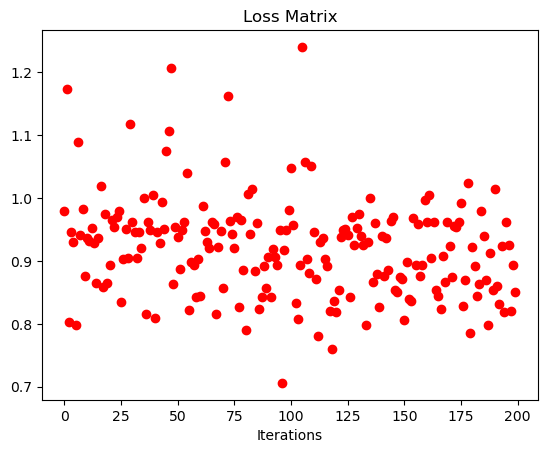

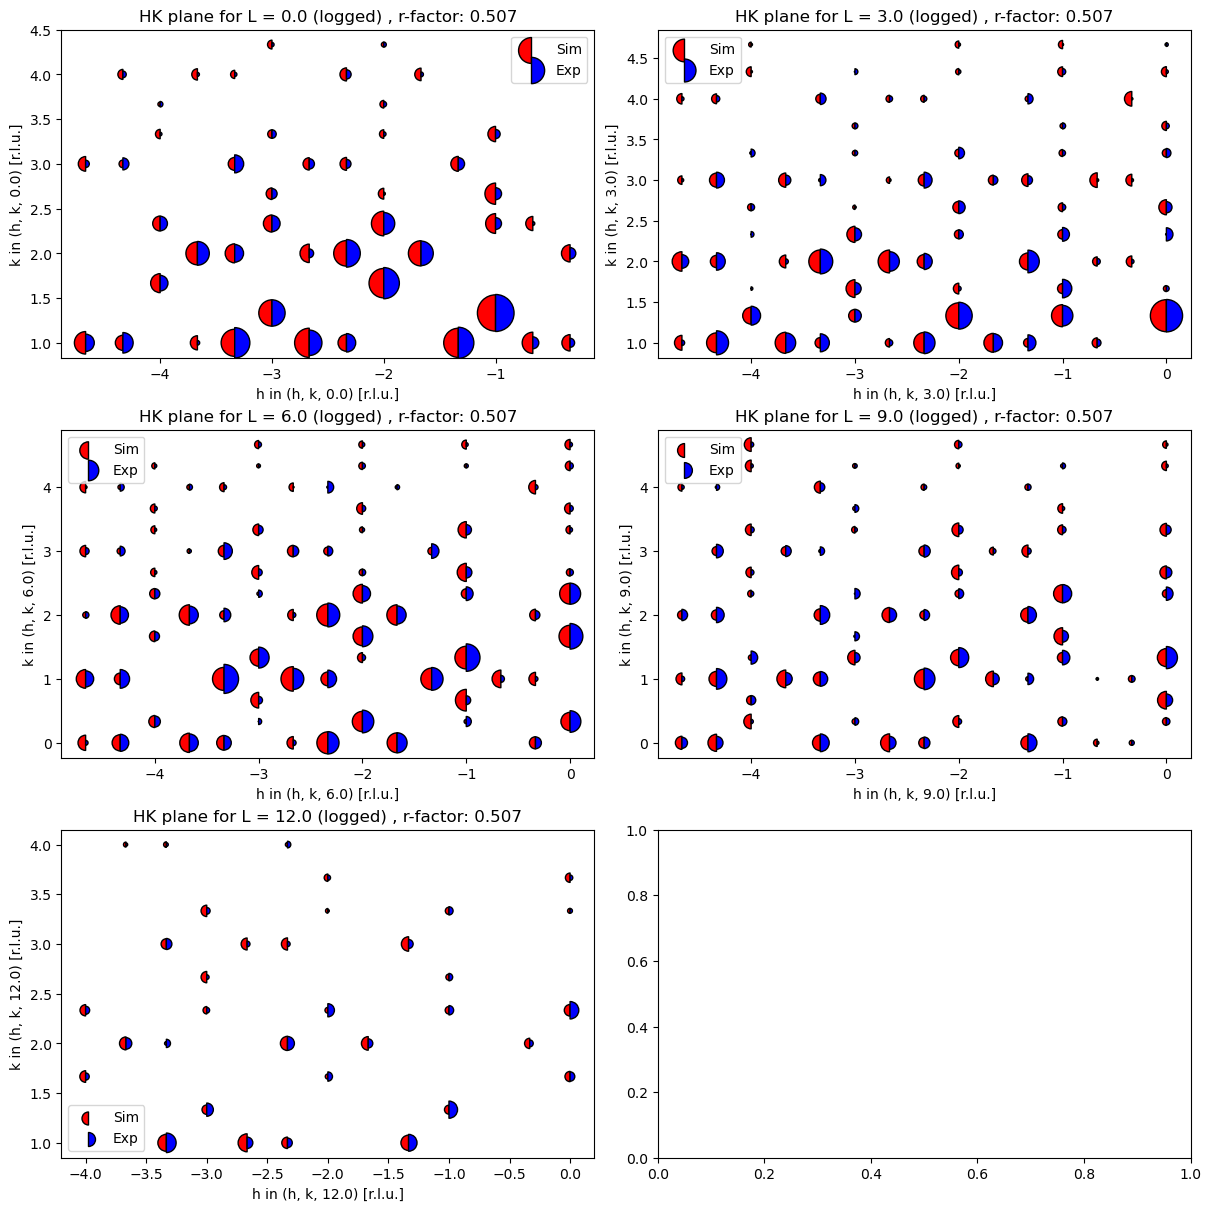

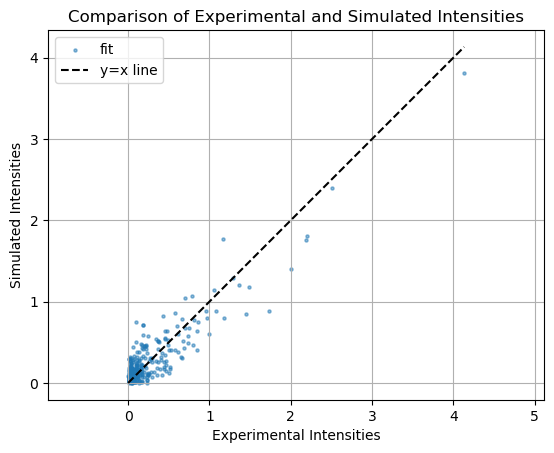

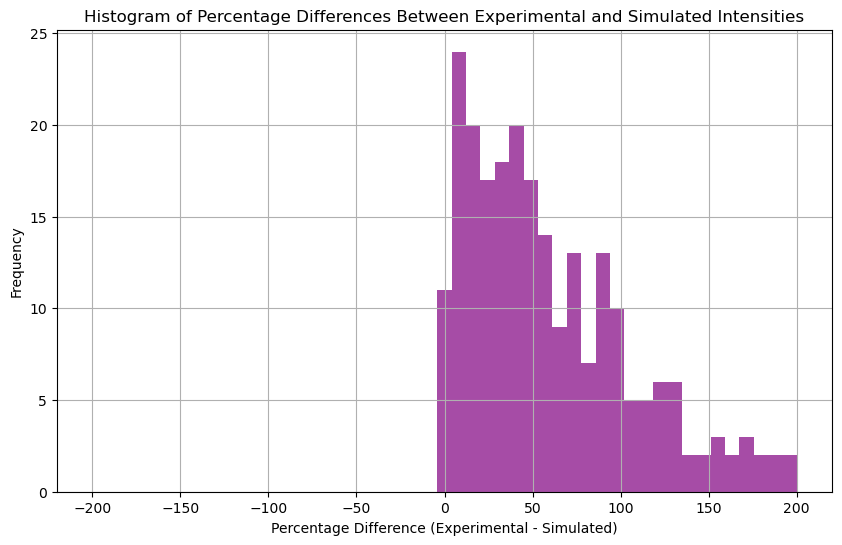

In [8]:
file_path = '20251008_071232_iters200_epochs1000_lr0.007'

#load file 
number_of_modes = 52
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_path}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# # export histogram as mat file
# import scipy.io as sio
# sio.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_path}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})